# train_gwn_v3.ipynb
**Graph WaveNet** — 12-horizon, VRAM-safe for GTX 1650 4GB

**Runs from:** `backend/model training/`

In [3]:
import os, gc, pickle, time, warnings, math
import numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as F
import scipy.sparse as sp, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings('ignore'); sns.set_theme(style='darkgrid')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

MODEL_NAME='gwn'; MODEL_DISPLAY='Graph WaveNet'
LOOKBACK=24; N_HORIZONS=12; RAW_FEAT_DIM=33; EMBED_DIM=32; IN_DIM=65
TRAIN_END=107; VAL_END=143; TEST_END=167
LR=2e-3; WARMUP_EP=5; PATIENCE=15; MAX_EPOCHS=80; WEIGHT_DECAY=1e-4

PROJECT_ROOT = None
for cand in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (cand / 'backend').exists() and (cand / 'requirements.txt').exists():
        PROJECT_ROOT = cand
        break
if PROJECT_ROOT is None:
    PROJECT_ROOT = Path.cwd().resolve()

DATA_DIR = PROJECT_ROOT / 'backend' / 'data generation' / 'data'
PROC_DIR = DATA_DIR / 'processed'
SCALER_DIR = DATA_DIR / 'scalers'
ADJ_DIR = DATA_DIR / 'graph_adj'
TENSOR_DIR = DATA_DIR / 'corridor_tensors'
MODEL_DIR = PROJECT_ROOT / 'backend' / 'models' / MODEL_NAME
os.makedirs(MODEL_DIR, exist_ok=True); os.makedirs(TENSOR_DIR, exist_ok=True)
print(f'PROJECT_ROOT={PROJECT_ROOT}')

def _save(o,p): torch.save(o, str(Path(p).resolve()))
def _load(p,**k): return torch.load(str(Path(p).resolve()), **k)

with open(f'{SCALER_DIR}/scaler_ttr.pkl','rb') as f: scaler_ttr=pickle.load(f)
with open(f'{SCALER_DIR}/scaler_cong.pkl','rb') as f: scaler_cong=pickle.load(f)
with open(f'{SCALER_DIR}/feat_meta.pkl','rb') as f: feat_meta=pickle.load(f)
assert feat_meta['RAW_FEAT_DIM']==RAW_FEAT_DIM

with open(f'{ADJ_DIR}/corridor_meta.pkl','rb') as f: corridor_meta=pickle.load(f)
corridors=sorted(corridor_meta.keys())
N_TOTAL_EDGES=sum(corridor_meta[c]['N'] for c in corridors)

with open(f'{PROC_DIR}/corridor_batch_map.pkl','rb') as f: corridor_batch_map=pickle.load(f)

df_static=pd.read_parquet(f'{PROC_DIR}/edges_static_scaled.parquet')
fftt_lookup=df_static.set_index('edge_id')['free_flow_travel_time'].to_dict()
del df_static; gc.collect()

print(f'Model: {MODEL_DISPLAY}, Corridors: {len(corridors)}, Edges: {N_TOTAL_EDGES:,}')

Device: cuda


FileNotFoundError: [Errno 2] No such file or directory: '../data generation/data/scalers/scaler_ttr.pkl'

In [ ]:
def build_corridor_tensors():
    done = f'{TENSOR_DIR}/.done_v4'
    if os.path.exists(done):
        print(f'Corridor tensors cached → {TENSOR_DIR}/'); return
    import glob as gl
    for f in gl.glob(f'{TENSOR_DIR}/corridor_*.pt'): os.remove(f)
    print('Building corridor tensors (batch-by-batch)...')
    t0 = time.perf_counter()
    batch_paths = sorted(gl.glob(f'{PROC_DIR}/batch_*.parquet'))
    feat_cols = feat_meta['ALL_FEAT_COLS']
    for cid in corridors:
        meta = corridor_meta[cid]; N = meta['N']
        tensor = np.zeros((N, 168, RAW_FEAT_DIM), dtype=np.float32)
        local_map = meta['local_map']
        for bi in corridor_batch_map.get(cid, []):
            df = pd.read_parquet(batch_paths[bi])
            cdf = df[df['corridor_id'] == cid]
            for eid in meta['edge_ids']:
                li = local_map.get(eid)
                if li is None: continue
                edf = cdf[cdf['edge_id'] == eid].sort_values('hour_index')
                if len(edf) == 0: continue
                tensor[li, edf['hour_index'].values, :] = edf[feat_cols].values.astype(np.float32)
            del df, cdf; gc.collect()
        _save(torch.from_numpy(tensor), f'{TENSOR_DIR}/corridor_{cid:04d}.pt')
        del tensor; gc.collect()
    with open(done, 'w') as f: f.write('v4')
    print(f'Done in {time.perf_counter()-t0:.1f}s')
build_corridor_tensors()

Corridor tensors cached → ../data generation/data/corridor_tensors/


In [3]:
def get_windows(split='train'):
    if split=='train': return list(range(LOOKBACK-1, TRAIN_END-N_HORIZONS+1))
    elif split=='val': return list(range(TRAIN_END-LOOKBACK+1, VAL_END-N_HORIZONS+1))
    else: return list(range(VAL_END-LOOKBACK+1, TEST_END-N_HORIZONS+1))

# ── VRAM-safe batch sizing for GTX 1650 4GB ──────────────────────────────────
# GWN: 8 blocks (2 layers × 4 dils), each with Conv1d + DiffConv(K=2, 2 adj)
# Memory per sample ≈ N × 300KB (forward activations + backward gradients)
# VRAM budget for activations: ~2.5GB (leaving 1.5GB for model+optim+embed+overhead)
MAX_N = 8000  # skip corridors above this (saves time, <1% of edges typically)
VRAM_ACT_BUDGET = 2.5e9  # 2.5 GB
MEM_PER_ELEM = 300_000   # bytes per N per sample (empirical for GWN 8-block)

def get_bs(N):
    bs = max(1, int(VRAM_ACT_BUDGET / (N * MEM_PER_ELEM)))
    return min(bs, 8)
    # N=500→8, N=1000→8, N=2000→4, N=4000→2, N=8000→1

train_windows=get_windows('train'); val_windows=get_windows('val'); test_windows=get_windows('test')
print(f'Windows: train={len(train_windows)} val={len(val_windows)} test={len(test_windows)}')
print(f'VRAM safety: MAX_N={MAX_N}, bs examples: N=500→{get_bs(500)}, N=2000→{get_bs(2000)}, N=5000→{get_bs(5000)}')

Windows: train=73 val=48 test=36
VRAM safety: MAX_N=8000, bs examples: N=500→8, N=2000→4, N=5000→1


In [1]:
class DiffConv(nn.Module):
    def __init__(s, ic, oc, K=2):
        super().__init__(); s.K=K; s.w=nn.Linear(ic*2*(K+1),oc)
    def forward(s, x, adj_list):
        B,N,C=x.shape; parts=[]
        for A in adj_list:
            h=x; parts.append(h)
            for k in range(1,s.K+1):
                h2 = torch.sparse.mm(A, h.reshape(B*N,C).T.reshape(N,B*C)).T.reshape(B,N,C) if A.is_sparse else torch.bmm(A.unsqueeze(0).expand(B,-1,-1),h)
                h=h2; parts.append(h)
        return s.w(torch.cat(parts,-1))

class GWNBlock(nn.Module):
    def __init__(s, rc, sc, dil, ks=2):
        super().__init__()
        s.fc=nn.Conv1d(rc,rc,ks,dilation=dil,padding=dil*(ks-1))
        s.gc=nn.Conv1d(rc,rc,ks,dilation=dil,padding=dil*(ks-1))
        s.dc=DiffConv(rc,rc,K=2); s.sk=nn.Conv1d(rc,sc,1); s.nm=nn.LayerNorm(rc)
    def forward(s, x, adj):
        B,N,T,C=x.shape; h=x.reshape(B*N,T,C).permute(0,2,1)
        h=torch.tanh(s.fc(h)[:,:,:T])*torch.sigmoid(s.gc(h)[:,:,:T])
        skip=s.sk(h).permute(0,2,1).reshape(B,N,T,-1)
        hl=h[:,:,-1].reshape(B,N,C); hs=s.dc(hl,adj)
        h=h.permute(0,2,1).reshape(B,N,T,C)
        h=h.clone(); h[:,:,-1,:]=h[:,:,-1,:]+hs
        return x+s.nm(h), skip

class GraphWaveNet(nn.Module):
    def __init__(s, in_dim=IN_DIM, rc=64, sc=128, nb=2, nl=4, nh=N_HORIZONS):
        super().__init__(); s.inp=nn.Linear(in_dim,rc)
        s.blocks=nn.ModuleList([GWNBlock(rc,sc,2**l) for _ in range(nb) for l in range(nl)])
        s.e1=nn.Conv1d(sc,sc,1); s.e2=nn.Conv1d(sc,nh,1)
    def forward(s, x, adj):
        B,N,T,_=x.shape; h=s.inp(x); ss=0
        for b in s.blocks: h,sk=b(h,adj); ss=ss+sk
        o=ss.mean(2).permute(0,2,1); return s.e2(F.relu(s.e1(o))).permute(0,2,1)
def build_model(): return GraphWaveNet()

NameError: name 'nn' is not defined

In [5]:
def load_adj(cid,N):
    with open(f'{ADJ_DIR}/corridor_{cid:04d}.pkl','rb') as f: ad=pickle.load(f)
    def sp2t(c,n):
        r,cl,v=c; i=torch.stack([torch.from_numpy(r.astype(np.int64)),torch.from_numpy(cl.astype(np.int64))])
        return torch.sparse_coo_tensor(i,torch.from_numpy(v),(n,n)).coalesce()
    return [sp2t(ad['A_fwd_coo'],N), sp2t(ad['A_bwd_coo'],N)]

def train_one_target(tidx, tname, sname, edge_emb):
    print(f'\n{"="*60}\n  {MODEL_DISPLAY} — {tname} (idx={tidx})\n{"="*60}')
    model=build_model().to(device)
    np_m=sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Params: {np_m:,} + embed: {sum(p.numel() for p in edge_emb.parameters()):,}')
    all_p=list(model.parameters())+list(edge_emb.parameters())
    opt=torch.optim.AdamW(all_p, lr=LR, weight_decay=WEIGHT_DECAY)
    sched=torch.optim.lr_scheduler.ReduceLROnPlateau(opt,'min',factor=0.5,patience=7,min_lr=1e-6)
    crit=nn.SmoothL1Loss(); best=float('inf'); pat=0
    hist={'train_loss':[],'val_loss':[],'lr':[]}
    skipped=set()

    for epoch in range(MAX_EPOCHS):
        te=time.perf_counter()
        for pg in opt.param_groups: pg['lr']=LR*min(1,(epoch+1)/WARMUP_EP)
        model.train(); edge_emb.train(); eloss=0; ns=0
        for cid in np.random.permutation(corridors):
            mc=corridor_meta[cid]; N=mc['N']
            if N<3 or N>MAX_N: continue
            data=_load(f'{TENSOR_DIR}/corridor_{cid:04d}.pt',weights_only=True)
            adj=load_adj(cid,N); adj=[a.to(device) for a in adj]
            gi=torch.from_numpy(mc['global_indices']).long().to(device)
            bs=get_bs(N); wi=np.random.permutation(train_windows)
            try:
                for s in range(0,len(wi),bs):
                    bt=wi[s:min(s+bs,len(wi))]
                    emb=edge_emb(gi)
                    xl,yl=[],[]
                    for t in bt:
                        xf=data[:,t-LOOKBACK+1:t+1,:].to(device)
                        xl.append(torch.cat([xf,emb.unsqueeze(1).expand(-1,LOOKBACK,-1)],dim=-1))
                        yl.append(data[:,t+1:t+1+N_HORIZONS,tidx].to(device))
                    x=torch.stack(xl); y=torch.stack(yl)
                    del xl,yl,emb  # free intermediates before forward pass
                    opt.zero_grad(); loss=crit(model(x,adj),y); loss.backward()
                    torch.nn.utils.clip_grad_norm_(all_p,5.0); opt.step()
                    eloss+=loss.item()*len(bt); ns+=len(bt)
                    del x,y,loss; torch.cuda.empty_cache()  # free after EACH mini-batch
            except RuntimeError as e:
                if 'out of memory' in str(e).lower():
                    if cid not in skipped:
                        print(f'    OOM at corridor {cid} (N={N}), skipping'); skipped.add(cid)
                    del data,adj,gi; torch.cuda.empty_cache(); gc.collect(); continue
                raise
            del data,adj,gi; torch.cuda.empty_cache()
        tl=eloss/max(ns,1)

        model.eval(); edge_emb.eval(); vs=0; vn=0
        with torch.no_grad():
            for cid in corridors:
                mc=corridor_meta[cid]; N=mc['N']
                if N<3 or N>MAX_N or cid in skipped: continue
                data=_load(f'{TENSOR_DIR}/corridor_{cid:04d}.pt',weights_only=True)
                adj=load_adj(cid,N); adj=[a.to(device) for a in adj]
                gi=torch.from_numpy(mc['global_indices']).long().to(device)
                emb=edge_emb(gi)
                for t in val_windows:
                    xf=data[:,t-LOOKBACK+1:t+1,:].to(device)
                    x=torch.cat([xf,emb.unsqueeze(1).expand(-1,LOOKBACK,-1)],dim=-1).unsqueeze(0)
                    y=data[:,t+1:t+1+N_HORIZONS,tidx].to(device).unsqueeze(0)
                    vs+=crit(model(x,adj),y).item(); vn+=1
                del data,adj,emb; torch.cuda.empty_cache()
        vl=vs/max(vn,1); hist['train_loss'].append(tl); hist['val_loss'].append(vl); hist['lr'].append(opt.param_groups[0]['lr'])
        if epoch>=WARMUP_EP: sched.step(vl)
        mk=''
        if vl<best: best=vl; pat=0; _save({'model':model.state_dict(),'embedding':edge_emb.state_dict()},f'{MODEL_DIR}/{sname}'); mk=' ★'
        else: pat+=1
        print(f'  Ep {epoch+1:3d} | trn={tl:.5f} val={vl:.5f} lr={opt.param_groups[0]["lr"]:.1e} | {time.perf_counter()-te:.0f}s{mk}')
        if pat>=PATIENCE: print('  Early stop'); break
        torch.cuda.empty_cache(); gc.collect()
    if skipped: print(f'  Note: {len(skipped)} corridors skipped (OOM): N up to {max(corridor_meta[c]["N"] for c in skipped)}')
    ck=_load(f'{MODEL_DIR}/{sname}',weights_only=True)
    model.load_state_dict(ck['model']); edge_emb.load_state_dict(ck['embedding'])
    return model, edge_emb, hist

In [6]:
edge_emb_ttr=nn.Embedding(N_TOTAL_EDGES,EMBED_DIM).to(device)
model_ttr, edge_emb_ttr, hist_ttr = train_one_target(0,'TTR','best_ttr.pt',edge_emb_ttr)
model_ttr.cpu(); edge_emb_ttr.cpu(); torch.cuda.empty_cache(); gc.collect()

edge_emb_cong=nn.Embedding(N_TOTAL_EDGES,EMBED_DIM).to(device)
model_cong, edge_emb_cong, hist_cong = train_one_target(1,'Congestion','best_cong.pt',edge_emb_cong)
model_ttr.to(device); edge_emb_ttr.to(device)
print(f'\n✓ Both saved to {MODEL_DIR}/')


  Graph WaveNet — TTR (idx=0)
  Params: 419,084 + embed: 4,648,480
  Ep   1 | trn=0.07415 val=0.06658 lr=4.0e-04 | 524s ★
  Ep   2 | trn=0.04806 val=0.05973 lr=8.0e-04 | 531s ★
  Ep   3 | trn=0.04718 val=0.05273 lr=1.2e-03 | 532s ★
  Ep   4 | trn=0.04185 val=0.08475 lr=1.6e-03 | 524s
  Ep   5 | trn=0.04716 val=0.06136 lr=2.0e-03 | 525s
  Ep   6 | trn=0.03693 val=0.06099 lr=2.0e-03 | 530s
  Ep   7 | trn=0.03742 val=0.07624 lr=2.0e-03 | 524s
  Ep   8 | trn=0.03930 val=0.05534 lr=2.0e-03 | 527s
  Ep   9 | trn=0.03695 val=0.06108 lr=2.0e-03 | 526s
  Ep  10 | trn=0.03244 val=0.06941 lr=2.0e-03 | 528s
  Ep  11 | trn=0.03782 val=0.05286 lr=2.0e-03 | 525s
  Ep  12 | trn=0.03236 val=0.05348 lr=2.0e-03 | 519s
  Ep  13 | trn=0.03555 val=0.05092 lr=2.0e-03 | 521s ★
  Ep  14 | trn=0.02715 val=0.05645 lr=2.0e-03 | 518s
  Ep  15 | trn=0.02783 val=0.05677 lr=2.0e-03 | 527s
  Ep  16 | trn=0.02753 val=0.10312 lr=2.0e-03 | 524s
  Ep  17 | trn=0.03285 val=0.04865 lr=2.0e-03 | 528s ★
  Ep  18 | trn=0.0279

In [7]:
def evaluate_model(model, emb, tidx, scaler):
    model.to(device); emb.to(device)
    model.eval(); emb.eval(); ap,aa,af=[],[],[]
    with torch.no_grad():
        for cid in corridors:
            mc=corridor_meta[cid]; N=mc['N']
            if N<3 or N>MAX_N: continue
            data=_load(f'{TENSOR_DIR}/corridor_{cid:04d}.pt',weights_only=True)
            adj=load_adj(cid,N); adj=[a.to(device) for a in adj]
            gi=torch.from_numpy(mc['global_indices']).long().to(device)
            e=emb(gi); ff=np.array([fftt_lookup.get(eid,30.) for eid in mc['edge_ids']],np.float32)
            for t in test_windows:
                xf=data[:,t-LOOKBACK+1:t+1,:].to(device)
                x=torch.cat([xf,e.unsqueeze(1).expand(-1,LOOKBACK,-1)],dim=-1).unsqueeze(0)
                y=data[:,t+1:t+1+N_HORIZONS,tidx]
                ap.append(model(x,adj).squeeze(0).cpu().numpy()); aa.append(y.numpy())
                af.append(np.tile(ff[:,None],(1,N_HORIZONS)))
            del data,adj; torch.cuda.empty_cache()
    p=np.concatenate(ap); a=np.concatenate(aa); f=np.concatenate(af)
    return p*scaler.scale_[0]+scaler.mean_[0], a*scaler.scale_[0]+scaler.mean_[0], f

ttr_p,ttr_a,ttr_f=evaluate_model(model_ttr,edge_emb_ttr,0,scaler_ttr)
cong_p,cong_a,_=evaluate_model(model_cong,edge_emb_cong,1,scaler_cong)
ttr_ps=ttr_p*ttr_f; ttr_as=ttr_a*ttr_f
print(f'TTR: {ttr_p.shape}, Cong: {cong_p.shape}')

TTR: (2099016, 12), Cong: (2099016, 12)


In [8]:
def metrics(p,a,name):
    r=[]
    for h in range(N_HORIZONS):
        pp,aa=p[:,h],a[:,h]; m=np.abs(aa)>0.1
        r.append({'h':h+1,'MAE':mean_absolute_error(aa,pp),'RMSE':np.sqrt(mean_squared_error(aa,pp)),
                  'R2':r2_score(aa,pp),'MAPE':np.mean(np.abs((aa[m]-pp[m])/aa[m]))*100 if m.sum()>0 else float('nan')})
    df=pd.DataFrame(r); print(f'\n── {name} ──'); print(df.to_string(index=False,float_format='%.4f')); return df
mt=metrics(ttr_p,ttr_a,'TTR ratio'); ms=metrics(ttr_ps,ttr_as,'TTR sec'); mc=metrics(cong_p,cong_a,'Congestion')


── TTR ratio ──
 h    MAE   RMSE     R2   MAPE
 1 0.0692 0.1280 0.5133 5.5230
 2 0.0697 0.1282 0.5118 5.5772
 3 0.0678 0.1223 0.5578 5.4629
 4 0.0664 0.1190 0.5863 5.2998
 5 0.0654 0.1176 0.5938 5.1888
 6 0.0714 0.1236 0.5462 5.7529
 7 0.0819 0.1337 0.4632 6.6527
 8 0.0887 0.1379 0.4220 7.1736
 9 0.0931 0.1387 0.4159 7.5836
10 0.0904 0.1354 0.4430 7.4006
11 0.0912 0.1345 0.4471 7.5683
12 0.0928 0.1363 0.4345 7.6636

── TTR sec ──
 h    MAE   RMSE     R2   MAPE
 1 0.8745 2.7057 0.9822 5.5230
 2 0.8795 2.7108 0.9822 5.5772
 3 0.8613 2.5890 0.9839 5.4629
 4 0.8508 2.5277 0.9849 5.2998
 5 0.8404 2.5043 0.9853 5.1888
 6 0.9163 2.6566 0.9835 5.7529
 7 1.0479 2.8484 0.9811 6.6527
 8 1.1333 2.9396 0.9800 7.1736
 9 1.1951 2.9758 0.9795 7.5836
10 1.1590 2.9149 0.9802 7.4006
11 1.1624 2.8841 0.9805 7.5683
12 1.1812 2.9095 0.9801 7.6636

── Congestion ──
 h    MAE   RMSE     R2    MAPE
 1 0.0422 0.0573 0.6546 22.8095
 2 0.0435 0.0581 0.6451 23.0643
 3 0.0415 0.0554 0.6782 21.9995
 4 0.0402 0.0527

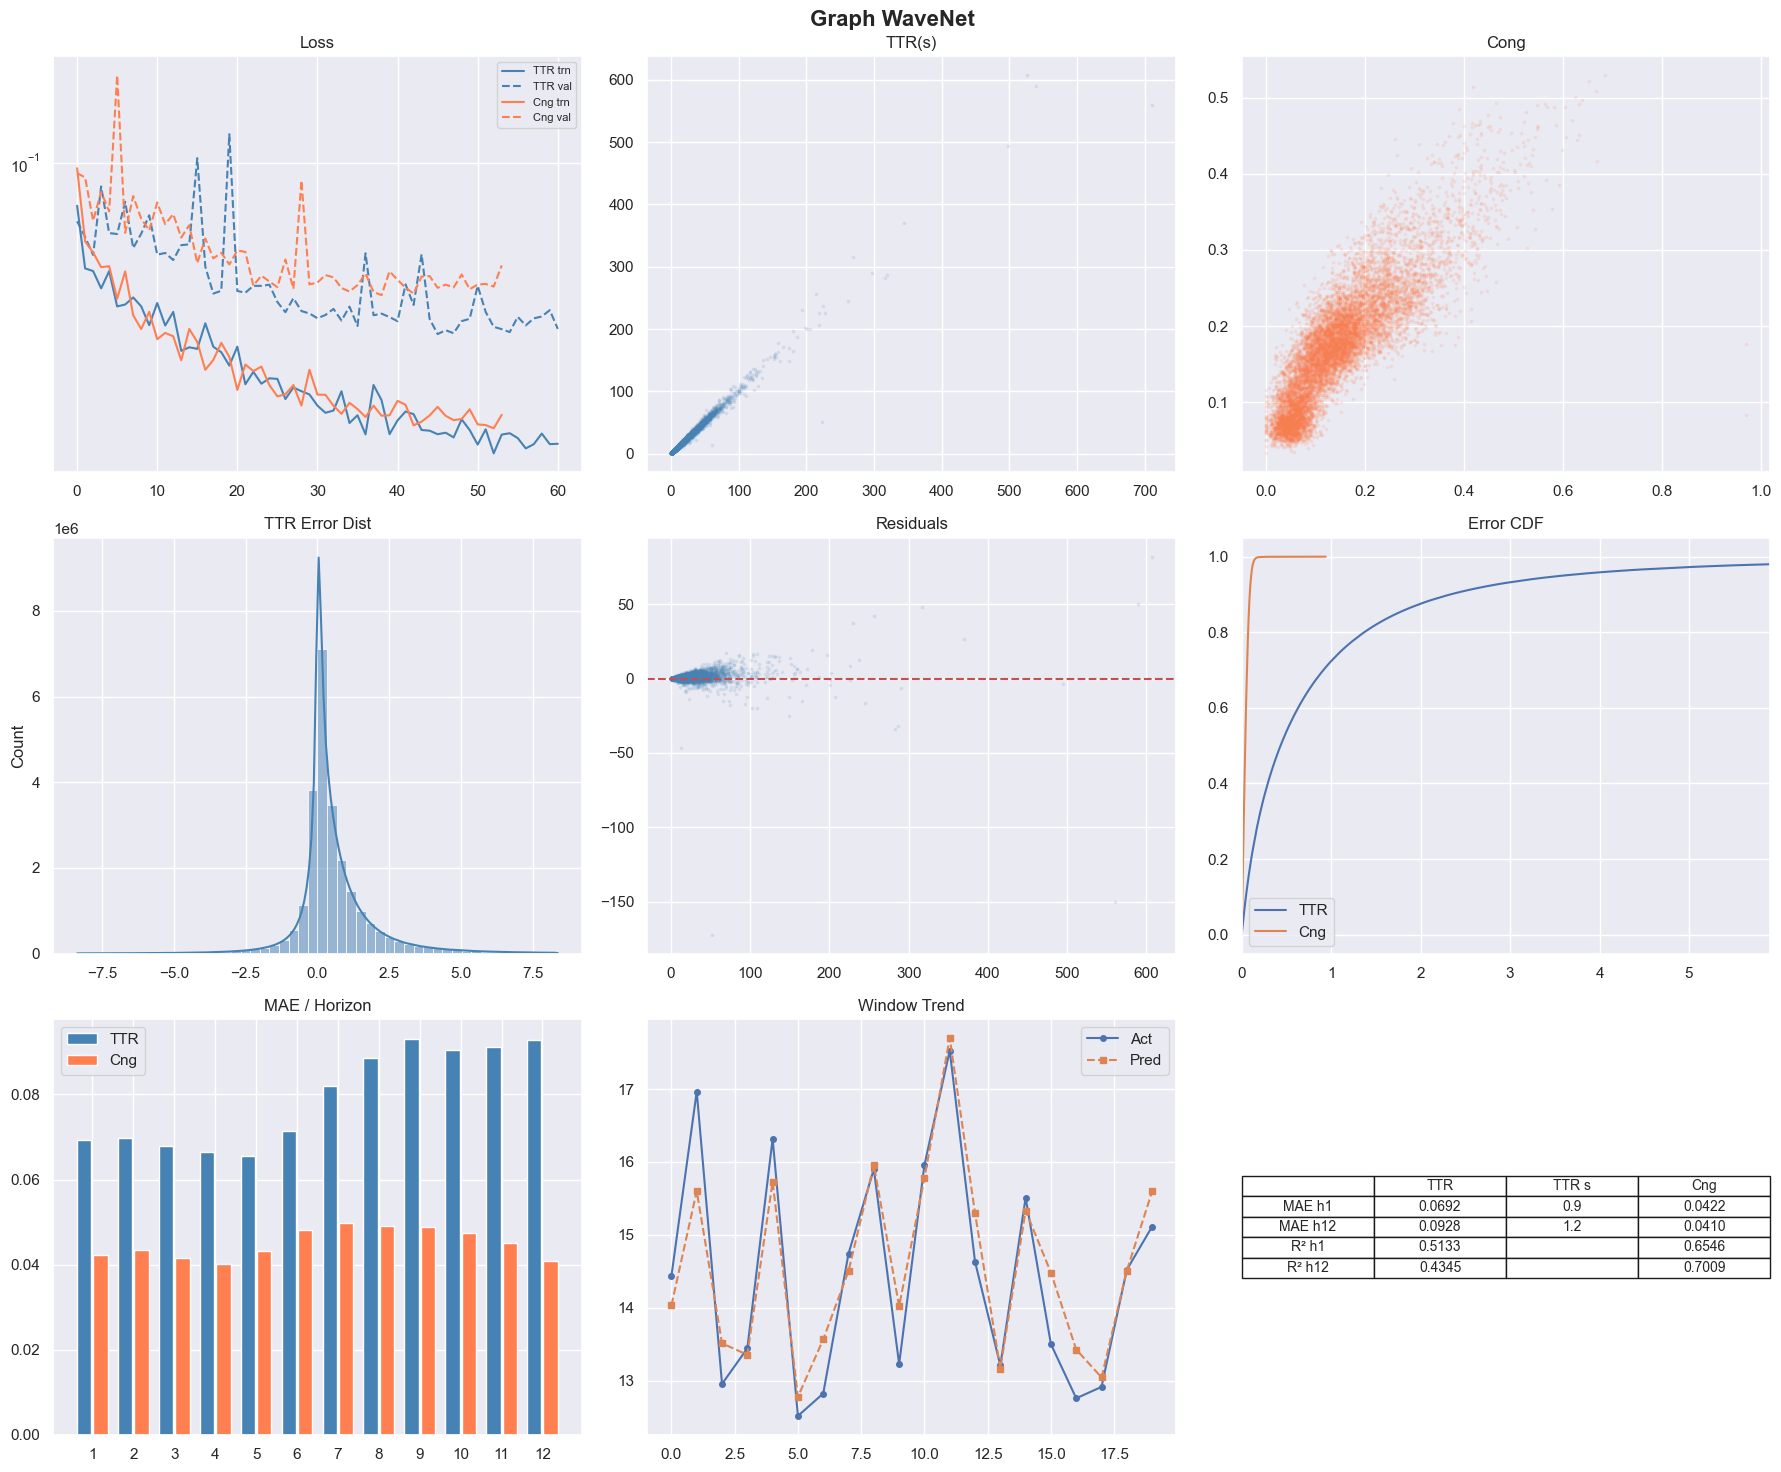

✓ Graph WaveNet complete.


In [10]:
# fig,ax=plt.subplots(3,3,figsize=(18,15)); fig.suptitle(f'{MODEL_DISPLAY}',fontsize=16,fontweight='bold')
# ax[0,0].plot(hist_ttr['train_loss'],label='TTR trn',color='steelblue'); ax[0,0].plot(hist_ttr['val_loss'],label='TTR val',color='steelblue',ls='--')
# ax[0,0].plot(hist_cong['train_loss'],label='Cng trn',color='coral'); ax[0,0].plot(hist_cong['val_loss'],label='Cng val',color='coral',ls='--')
# ax[0,0].legend(fontsize=8); ax[0,0].set_yscale('log'); ax[0,0].set_title('Loss')
# ns=min(10000,ttr_ps.size); ii=np.random.choice(ttr_ps.size,ns,replace=False)
# ax[0,1].scatter(ttr_as.flat[ii],ttr_ps.flat[ii],alpha=.1,s=3,c='steelblue'); ax[0,1].set_title('TTR(s)')
# ax[0,2].scatter(cong_a.flat[ii],cong_p.flat[ii],alpha=.1,s=3,c='coral'); ax[0,2].set_title('Cong')
# te=ttr_p.flat-ttr_a.flat; ce=cong_p.flat-cong_a.flat
# sns.histplot(te[np.abs(te)<np.percentile(np.abs(te),99)],kde=True,ax=ax[1,0],color='steelblue',bins=50)
# ax[1,1].scatter(ttr_p.flat[ii],te[ii],alpha=.1,s=3,c='steelblue'); ax[1,1].axhline(0,c='r',ls='--')
# ta=np.sort(np.abs(te)); ca=np.sort(np.abs(ce))
# ax[1,2].plot(ta,np.linspace(0,1,len(ta)),label='TTR'); ax[1,2].plot(ca,np.linspace(0,1,len(ca)),label='Cng')
# ax[1,2].set_xlim(0,np.percentile(ta,98)); ax[1,2].legend()
# xh=mt['h'].values; ax[2,0].bar(xh-.2,mt['MAE'],.35,label='TTR',color='steelblue'); ax[2,0].bar(xh+.2,mc['MAE'],.35,label='Cng',color='coral')
# ax[2,0].set_xticks(xh); ax[2,0].legend(); ax[2,0].set_title('MAE/Horizon')
# ch=max(1,ttr_as.shape[0]//len(test_windows)); nw=min(len(test_windows),20)
# ax[2,1].plot([ttr_as[i*ch:(i+1)*ch,0].mean() for i in range(nw)],'o-',label='Act',ms=4)
# ax[2,1].plot([ttr_ps[i*ch:(i+1)*ch,0].mean() for i in range(nw)],'s--',label='Pred',ms=4); ax[2,1].legend()
# ax[2,2].axis('off')
# s=[['','TTR','TTR s','Cng'],['MAE h1',f'{mt.iloc[0]["MAE"]:.4f}',f'{ms.iloc[0]["MAE"]:.1f}',f'{mc.iloc[0]["MAE"]:.4f}'],
#    ['MAE h12',f'{mt.iloc[11]["MAE"]:.4f}',f'{ms.iloc[11]["MAE"]:.1f}',f'{mc.iloc[11]["MAE"]:.4f}'],
#    ['R² h1',f'{mt.iloc[0]["R2"]:.4f}','',f'{mc.iloc[0]["R2"]:.4f}'],['R² h12',f'{mt.iloc[11]["R2"]:.4f}','',f'{mc.iloc[11]["R2"]:.4f}']]
# ax[2,2].table(cellText=s[1:],colLabels=s[0],loc='center',cellLoc='center').auto_set_font_size(False)
# plt.tight_layout(); plt.savefig(f'{MODEL_DIR}/eval.png',dpi=150,bbox_inches='tight'); plt.show()
# print(f'✓ {MODEL_DISPLAY} complete.')
fig, ax = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle(f'{MODEL_DISPLAY}', fontsize=16, fontweight='bold')

# ── Loss ─────────────────────────────────────────────
ax[0,0].plot(hist_ttr['train_loss'], label='TTR trn', color='steelblue')
ax[0,0].plot(hist_ttr['val_loss'], label='TTR val', color='steelblue', ls='--')
ax[0,0].plot(hist_cong['train_loss'], label='Cng trn', color='coral')
ax[0,0].plot(hist_cong['val_loss'], label='Cng val', color='coral', ls='--')
ax[0,0].legend(fontsize=8)
ax[0,0].set_yscale('log')
ax[0,0].set_title('Loss')

# ── Flatten once (important for speed) ───────────────
ttr_a_flat = ttr_as.ravel()
ttr_p_flat = ttr_ps.ravel()
cong_a_flat = cong_a.ravel()
cong_p_flat = cong_p.ravel()

# ── Sampling ─────────────────────────────────────────
ns = min(10000, ttr_p_flat.size)
ii = np.random.choice(ttr_p_flat.size, ns, replace=False)

# ── Scatter plots ───────────────────────────────────
ax[0,1].scatter(ttr_a_flat[ii], ttr_p_flat[ii], alpha=0.1, s=3, c='steelblue')
ax[0,1].set_title('TTR(s)')

ax[0,2].scatter(cong_a_flat[ii], cong_p_flat[ii], alpha=0.1, s=3, c='coral')
ax[0,2].set_title('Cong')

# ── Errors ───────────────────────────────────────────
te = ttr_p_flat - ttr_a_flat
ce = cong_p_flat - cong_a_flat

# Histogram (clip outliers)
te_clip = te[np.abs(te) < np.percentile(np.abs(te), 99)]
sns.histplot(te_clip, kde=True, ax=ax[1,0], color='steelblue', bins=50)
ax[1,0].set_title('TTR Error Dist')

# Residual plot
ax[1,1].scatter(ttr_p_flat[ii], te[ii], alpha=0.1, s=3, c='steelblue')
ax[1,1].axhline(0, c='r', ls='--')
ax[1,1].set_title('Residuals')

# CDF
ta = np.sort(np.abs(te))
ca = np.sort(np.abs(ce))
ax[1,2].plot(ta, np.linspace(0, 1, len(ta)), label='TTR')
ax[1,2].plot(ca, np.linspace(0, 1, len(ca)), label='Cng')
ax[1,2].set_xlim(0, np.percentile(ta, 98))
ax[1,2].legend()
ax[1,2].set_title('Error CDF')

# ── MAE vs Horizon ───────────────────────────────────
xh = mt['h'].values
ax[2,0].bar(xh - 0.2, mt['MAE'], 0.35, label='TTR', color='steelblue')
ax[2,0].bar(xh + 0.2, mc['MAE'], 0.35, label='Cng', color='coral')
ax[2,0].set_xticks(xh)
ax[2,0].legend()
ax[2,0].set_title('MAE / Horizon')

# ── Window trend ─────────────────────────────────────
ch = max(1, ttr_as.shape[0] // len(test_windows))
nw = min(len(test_windows), 20)

ax[2,1].plot(
    [ttr_as[i*ch:(i+1)*ch, 0].mean() for i in range(nw)],
    'o-', label='Act', ms=4
)
ax[2,1].plot(
    [ttr_ps[i*ch:(i+1)*ch, 0].mean() for i in range(nw)],
    's--', label='Pred', ms=4
)
ax[2,1].legend()
ax[2,1].set_title('Window Trend')

# ── Summary table ────────────────────────────────────
ax[2,2].axis('off')

summary = [
    ['', 'TTR', 'TTR s', 'Cng'],
    ['MAE h1',  f'{mt.iloc[0]["MAE"]:.4f}',  f'{ms.iloc[0]["MAE"]:.1f}',  f'{mc.iloc[0]["MAE"]:.4f}'],
    ['MAE h12', f'{mt.iloc[11]["MAE"]:.4f}', f'{ms.iloc[11]["MAE"]:.1f}', f'{mc.iloc[11]["MAE"]:.4f}'],
    ['R² h1',   f'{mt.iloc[0]["R2"]:.4f}',   '',                          f'{mc.iloc[0]["R2"]:.4f}'],
    ['R² h12',  f'{mt.iloc[11]["R2"]:.4f}',  '',                          f'{mc.iloc[11]["R2"]:.4f}']
]

table = ax[2,2].table(
    cellText=summary[1:], colLabels=summary[0],
    loc='center', cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)

# ── Finalize ─────────────────────────────────────────
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/eval.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'✓ {MODEL_DISPLAY} complete.')

In [ ]:
# Load pretrained GWN weights without retraining
if 'GWN' not in globals() or 'EdgeEmbedding' not in globals():
    raise RuntimeError(
        "Model classes are not in memory. Run the model-definition/training-setup cells first."
    )

ck = _load(MODEL_DIR / 'best_ttr.pt', weights_only=True)

model_ttr = GWN(IN_DIM, N_HORIZONS).to(device)
edge_emb_ttr = EdgeEmbedding(N_TOTAL_EDGES, EMBED_DIM).to(device)

model_ttr.load_state_dict(ck['model'])
edge_emb_ttr.load_state_dict(ck['embedding'])

model_ttr.eval()
edge_emb_ttr.eval()
print('Loaded best_ttr.pt for export')

NameError: name 'GWN' is not defined